# Formation Usage Overview
Visualize how often each formation has been used (home + away) across the 95 matches played so far, inspired by the reference layout.

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import VerticalPitch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


plt.style.use("seaborn-v0_8-white")
DATA_DIR = Path("..") / "data" / "processed"
MATCHES_METADATA_PATH = DATA_DIR / "matches_metadata.csv"
BKG_IMG_PATH = Path("..") / "outputs" / "figures" / "tabla.png"
LOGO_PATH = Path("..") / "outputs" / "figures" / "pfp.png"

In [2]:
matches = pd.read_csv(MATCHES_METADATA_PATH, parse_dates=["match_datetime"])
formation_cols = ["homeTeam_formation", "awayTeam_formation"]
available_cols = [col for col in formation_cols if col in matches.columns]
if len(available_cols) != 2:
    raise ValueError(f"Expected both formation columns, found: {available_cols}")

formation_usage = (
    matches.melt(
        id_vars=["match_id", "round", "match_date"],
        value_vars=available_cols,
        var_name="team_side",
        value_name="formation",
    )
    .dropna(subset=["formation"])
    .assign(team_side=lambda df: df["team_side"].str.replace("Team_formation", ""))
)

total_formations = len(formation_usage)
formation_counts = (
    formation_usage.groupby("formation")
    .size()
    .reset_index(name="appearances")
    .sort_values("appearances", ascending=False)
)
formation_counts["share"] = (formation_counts["appearances"] / total_formations * 100).round(1)
formation_top = formation_counts.head(6).reset_index(drop=True)

formation_counts

,formation,appearances,share
6,4-2-3-1,117,46.8
4,4-1-4-1,38,15.2
11,4-4-2,35,14.0
14,5-4-1,11,4.4
9,4-3-3,9,3.6
12,4-5-1,7,2.8
10,4-4-1-1,6,2.4
13,5-3-2,6,2.4
0,3-4-2-1,4,1.6
7,4-3-1-2,4,1.6


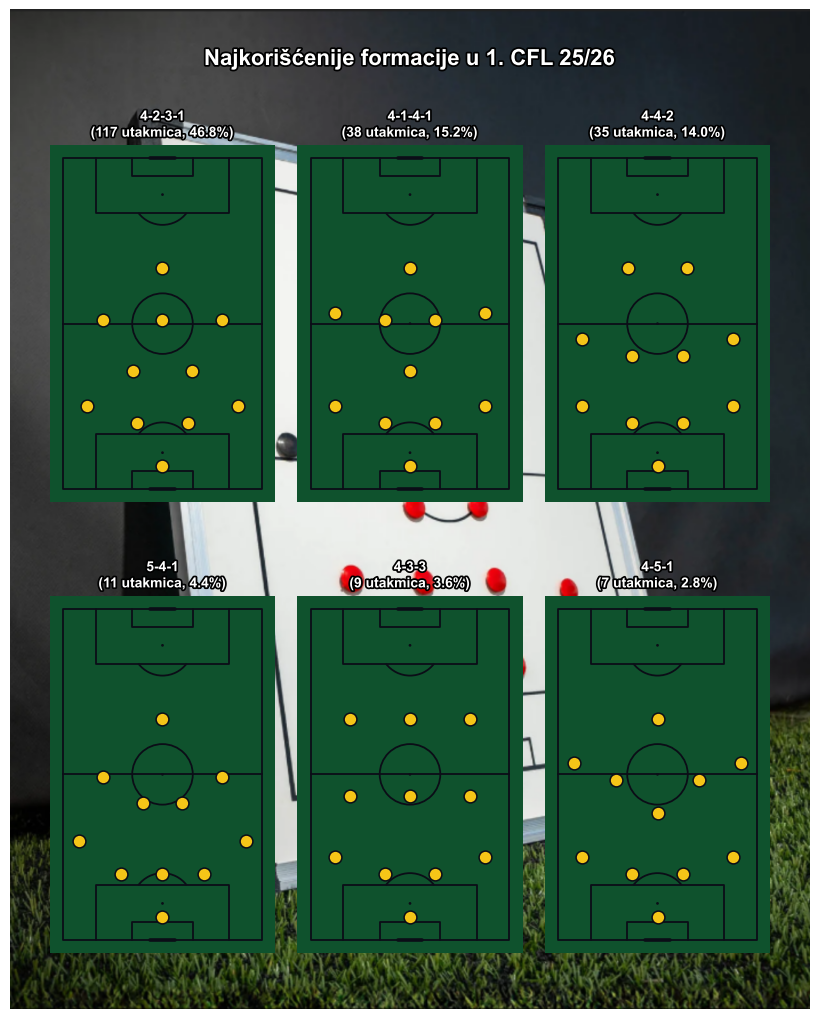

In [3]:
import matplotlib.patheffects as path_effects

background_img = plt.imread(BKG_IMG_PATH)


PITCH_LENGTH = 100
PITCH_WIDTH = 60
LINE_COLOR = '#0b0d17'
DOT_COLOR = '#f5c518'
DOT_EDGE = '#0b0d17'
PITCH_COLOR = (15 / 255, 82 / 255, 45 / 255, 1.0)  

pitch_template = VerticalPitch(
    pitch_type='custom',
    pitch_length=PITCH_LENGTH,
    pitch_width=PITCH_WIDTH,
    pitch_color=PITCH_COLOR,
    line_color=LINE_COLOR,
    line_zorder=3,
    linewidth=1.3,
)


def _formation_positions(formation: str, length: float = PITCH_LENGTH, width: float = PITCH_WIDTH):
    try:
        lines = [int(part) for part in formation.split('-')]
    except ValueError:
        raise ValueError(f"Unexpected formation format: {formation}")

    # Goalkeeper at bottom
    positions = [(width / 2, 7)]
    # More compact formation - most forward player at 1/3 from top
    y_start = 20
    y_end = length * 2/3  # 1/3 from top means 2/3 from bottom
    y_values = np.linspace(y_start, y_end, num=len(lines)) if lines else []

    for line_idx, (y, count) in enumerate(zip(y_values, lines)):
        if count <= 0:
            continue
        if count == 1:
            # Single player - center
            x_values = [width / 2]
            y_positions = [y] * count
        elif count == 2:
            # Two players - narrower (e.g., two strikers, two defensive mids)
            x_values = np.linspace(width * 0.35, width * 0.65, num=count)
            y_positions = [y] * count
        elif count == 3:
            # Three players - moderate width (e.g., attacking trio)
            x_values = np.linspace(width * 0.20, width * 0.80, num=count)
            y_positions = [y] * count
        elif count == 4:
            # Four players - wider (e.g., defensive line, midfield)
            x_values = np.linspace(width * 0.12, width * 0.88, num=count)
            # If this is the first line (defensive line), push wing-backs forward more
            if line_idx == 0:
                y_positions = [y + 5, y, y, y + 5]  # Outside defenders higher
            # Special case for 5-4-1: second line (midfield) with special positioning
            elif formation == '5-4-1' and line_idx == 1:
                # Outside mids forward and more central, central mids back
                x_values = [width * 0.20, width * 0.40, width * 0.60, width * 0.80]
                y_positions = [y + 6, y - 2, y - 2, y + 6]
            # Special case for 4-4-1-1: second line (midfield) with outside players forward
            elif formation == '4-4-1-1' and line_idx == 1:
                y_positions = [y + 4, y, y, y + 4]  # Outside mids forward
            # Special case for 4-4-2: second line (midfield) with central players lower
            elif formation == '4-4-2' and line_idx == 1:
                y_positions = [y + 2, y - 3, y - 3, y + 2]  # Central mids lower
            # For other midfield lines, push outside players slightly forward
            else:
                y_positions = [y + 2, y, y, y + 2]  # Outside midfielders slightly higher
        elif count == 5:
            # Five players - widest (e.g., 5-back formation)
            x_values = np.linspace(width * 0.08, width * 0.92, num=count)
            # Special case for 5-4-1: first line (defensive) with 3 middle same height
            if formation == '5-4-1' and line_idx == 0:
                y_positions = [y + 10, y, y, y, y + 10]  # Outside defenders higher, 3 middle same
            # If this is the first line (defensive line), push wing-backs forward more
            elif line_idx == 0:
                y_positions = [y + 6, y + 2, y, y + 2, y + 6]  # Outside defenders higher
            # Special case for 4-5-1: second line (midfield) with special positioning
            elif formation == '4-5-1' and line_idx == 1:
                y_positions = [y + 10, y + 5, y - 5, y + 5, y + 10]  # Outside mids forward, central mid back
            else:
                y_positions = [y] * count
        else:
            # Fallback for unusual numbers
            x_values = np.linspace(10, width - 10, num=count)
            y_positions = [y] * count
        
        for x, y_pos in zip(x_values, y_positions):
            positions.append((x, y_pos))
    return np.array(positions)


def plot_formation_grid(counts_df: pd.DataFrame, background=None):
    n = len(counts_df)
    n_cols = 3
    n_rows = math.ceil(n / n_cols)
    
    # 4:5 aspect ratio (width:height) - using exact dimensions
    fig_width = 8  # inches
    fig_height = 10  # inches (4:5 ratio)
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=100)
    
    # Add background as a full-figure axes behind everything
    if background is not None:
        ax_bg = fig.add_axes([0, 0, 1, 1], zorder=-1)
        ax_bg.imshow(background, aspect='auto', extent=[0, 1, 0, 1])
        ax_bg.axis('off')
    
    # Create grid
    axes = fig.subplots(n_rows, n_cols)
    axes = np.array(axes).reshape(n_rows, n_cols)

    for ax_idx, (_, row) in enumerate(counts_df.iterrows()):
        ax = axes.flat[ax_idx]
        pitch_template.draw(ax=ax)
        coords = _formation_positions(row['formation'])
        ax.scatter(
            coords[:, 0],
            coords[:, 1],
            s=85,
            color=DOT_COLOR,
            edgecolors=DOT_EDGE,
            linewidth=1.1,
            zorder=5,
        )
        title = ax.set_title(
            f"{row['formation']}\n({row['appearances']} utakmica, {row['share']}%)",
            fontsize=10,
            weight='bold',
            color='white',
            pad=6,
        )
        title.set_path_effects([
            path_effects.Stroke(linewidth=2.5, foreground='black'),
            path_effects.Normal()
        ])

    for ax in axes.flat[n:]:
        ax.axis('off')

    suptitle = fig.suptitle(
        "Najkorišćenije formacije u 1. CFL 25/26",
        fontsize=16,
        weight='bold',
        color='white',
        y=0.96,
    )
    suptitle.set_path_effects([
        path_effects.Stroke(linewidth=2.5, foreground='black'),
        path_effects.Normal()
    ])
    
    # Adjusted spacing: bigger pitches, less gap between rows, more top padding, less bottom padding
    fig.subplots_adjust(left=0.05, right=0.95, top=0.90, bottom=0.02, hspace=0.05, wspace=0.1)
    return fig


_ = plot_formation_grid(formation_top, background=background_img)

In [5]:
# Save figure maintaining exact 4:5 aspect ratio
OUTPUT_DIR = Path("..") / "outputs" / "final_posts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

fig = plot_formation_grid(formation_top, background=background_img)
output_path = OUTPUT_DIR / "formations.png"

# Save at 300 DPI: 8x10 inches = 2400x3000 pixels (exactly 4:5)
fig.savefig(output_path, dpi=300, format='png')
plt.close(fig)

# Verify dimensions
from PIL import Image
img = Image.open(output_path)
width, height = img.size
ratio = width / height
print(f"Saved: {width}x{height} pixels")
print(f"Aspect ratio: {ratio:.3f} (target: 0.800 for 4:5)")

Saved: 2400x3000 pixels
Aspect ratio: 0.800 (target: 0.800 for 4:5)
